# CNN Exercise — Starter Notebook
## Simple CNN Image Classifier (Intel Image Classification)

Dataset: https://www.kaggle.com/datasets/puneet6060/intel-image-classification

Fill in each `# TODO` below. Read the comments carefully — they explain
**what** each piece needs to do and **why**, without giving you the exact
code, so you actually have to think it through.

See `cnn_exercise_simple.md` for the full task write-up, and
`cnn_concept_notes_simple.md` for the plain-English concept explanations
if you get stuck on *why* a step exists.

Run cells top to bottom as you fill them in — later cells depend on
variables defined in earlier ones.

## Setup

Run this once to install dependencies (skip if already installed).

In [1]:
!pip install tensorflow scikit-learn matplotlib -q

## Imports and configuration

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

TRAIN_DIR = "dataset/intel_data/seg_train/seg_train"
TEST_DIR = "dataset/intel_data/seg_test/seg_test"
IMG_SIZE = (100, 100)   # smaller than the original 150x150 -> faster training
BATCH_SIZE = 32
SEED = 42               # keep this fixed so your train/val split is reproducible
CLASS_NAMES = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

## Task 1 — Look at the data

Before writing any preprocessing code, get a feel for what you're working
with. This matters more than it sounds like — a lot of real-world bugs
come from assumptions about data that turn out to be wrong (folders in a
different order than expected, unexpected file types mixed in, etc).

**What to do:**
1. Loop over `CLASS_NAMES`, count how many files are in each
   `TRAIN_DIR/<class_name>` folder, and print the counts. You should find
   they're roughly balanced across all 6 classes (that's one of the reasons
   this dataset is a good "simple" starting point).
2. Load and display a couple of sample images from at least 2-3 classes,
   just to visually confirm the folders contain what their names claim.

**Hints:**
- `os.listdir(path)` gives you a list of filenames in a folder.
- `tf.keras.utils.load_img(filepath)` loads an image you can pass straight
  to `plt.imshow()`.

In [2]:
# TODO: count images per class and print the results
for class_name in CLASS_NAMES:
    class_path = os.path.join(TRAIN_DIR, class_name)
    count = len(os.listdir(class_path))
    print(f"Class '{class_name}': {count} images")

Class 'buildings': 2191 images
Class 'forest': 2271 images
Class 'glacier': 2404 images
Class 'mountain': 2512 images
Class 'sea': 2274 images
Class 'street': 2382 images


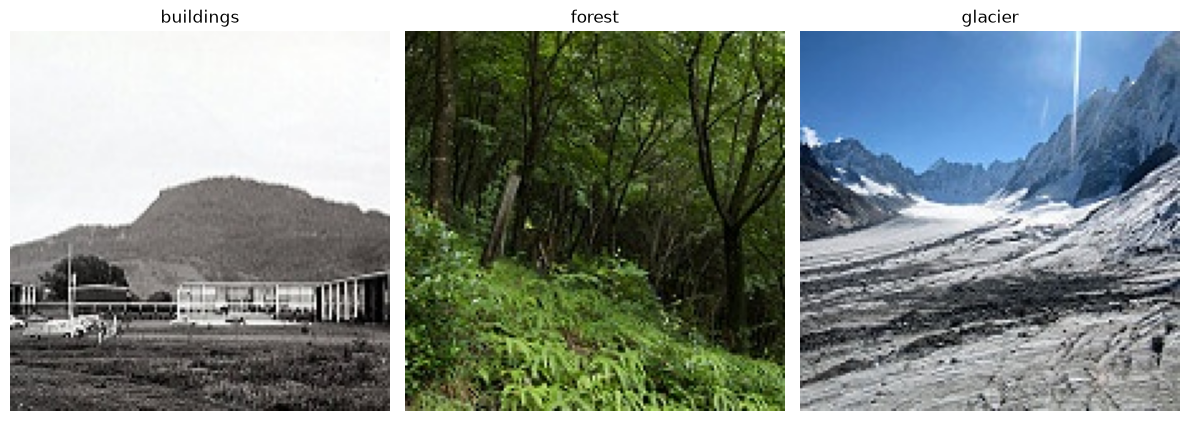

In [3]:
# TODO: display 2-3 sample images from different classes using plt.imshow()
plt.figure(figsize=(12, 6))
sample_classes = ["buildings", "forest", "glacier"]

for i, class_name in enumerate(sample_classes):
    class_path = os.path.join(TRAIN_DIR, class_name)
    sample_file = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, sample_file)

    img = tf.keras.utils.load_img(img_path)

    plt.subplot(1, len(sample_classes), i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Task 2 — Load and preprocess

Rather than manually resizing/loading every image yourself, use
`tf.keras.utils.image_dataset_from_directory` — it does the heavy lifting:
reads images from disk in batches, resizes them, infers labels from folder
names, and batches everything for you.

**What to do:**

1. Call `image_dataset_from_directory` on `TRAIN_DIR` **twice**:
   - once with `subset="training"` and `validation_split=0.15`
   - once with `subset="validation"` and the same `validation_split=0.15`
   - Pass the **same** `seed=SEED` to both calls — this is what makes the
     split consistent, so the two calls produce non-overlapping subsets
     rather than two random 85%/15% splits that might overlap.
   - Pass `image_size=IMG_SIZE` and `batch_size=BATCH_SIZE` to both.

2. Call it a third time on `TEST_DIR`, with no `validation_split` (it's
   already a separate folder) and `shuffle=False` (so predictions line up
   with true labels later when you evaluate).

3. Think about why we do NOT want to shuffle the test set but it's fine
   for the training set to be shuffled — write yourself a one-line note
   on this before moving on.

**Hints:**
- Function signature: `tf.keras.utils.image_dataset_from_directory(directory, validation_split=..., subset=..., seed=..., image_size=..., batch_size=..., shuffle=...)`
- Consider adding `.cache().prefetch(tf.data.AUTOTUNE)` to each dataset
  afterward — this is a performance optimization (lets TensorFlow prepare
  the next batch while the current one trains) and not conceptually
  required, but good practice.

In [4]:
# TODO: load train_ds using image_dataset_from_directory
# train_ds = ...
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.15,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
).cache().prefetch(buffer_size=tf.data.AUTOTUNE)



Found 14034 files belonging to 6 classes.
Using 11929 files for training.


In [5]:
# TODO: load val_ds using image_dataset_from_directory (same seed/split as above)
# val_ds = ...
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.15,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 14034 files belonging to 6 classes.
Using 2105 files for validation.


In [6]:
# TODO: load test_ds using image_dataset_from_directory (no validation_split, shuffle=False)
# test_ds = ...
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 3000 files belonging to 6 classes.


### Augmentation layer

Augmentation should be applied **only** to training data — never to
validation or test data, since those need to reflect real, unmodified
images to give you an honest measure of performance. (Good news: if you
build this as a Keras layer and include it inside your model in Task 3,
Keras automatically turns it off during evaluation/prediction for you —
you don't need to write separate logic to avoid augmenting val/test.)

**What to do:**
Build a small `tf.keras.Sequential` containing:
- `layers.RandomFlip("horizontal")` — a mirrored photo of a mountain is
  still a mountain, so this is a safe transformation.
- `layers.RandomRotation(...)` — pick a small value (~0.05, meaning up to
  ~5% of 360°) to mimic a camera not held perfectly level.
- `layers.RandomZoom(...)` — pick a small value (~0.1) to mimic photos
  taken from slightly different distances.

Think about why we keep these values small rather than large (e.g. why
not rotate up to 50%?) before choosing your numbers.

In [7]:
# TODO: build and return a Sequential of augmentation layers
def make_augmentation_layer():
    return tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
    ])
    raise NotImplementedError


## Task 3 — Build the CNN

Keep it small — this is a 6-class problem but the images are visually
distinct, so a deep network isn't necessary.

**What your model needs, in order:**
1. An `Input` layer matching `input_shape`.
2. A `Rescaling(1.0/255)` layer — converts raw 0-255 pixel values down to
   0-1. Put this INSIDE the model (not as a separate preprocessing step)
   so it automatically applies at prediction time too, later.
3. Your augmentation layer from above.
4. 2-3 blocks of `Conv2D(...) -> MaxPooling2D((2,2))`. Increase the number
   of filters as you go deeper (e.g. 32 -> 64 -> 128) — as spatial size
   shrinks through pooling, deeper layers typically need more filters to
   represent more complex patterns.
5. A `Flatten()` layer — converts the final 3D feature maps into a flat
   1D vector, since Dense layers need a flat input.
6. A `Dropout(...)` layer (try 0.3) before your dense layers — randomly
   zeroes out some values during training to reduce overfitting.
7. A `Dense(...)` layer with `relu` activation to combine everything
   detected so far.
8. A final `Dense(len(CLASS_NAMES), activation="softmax")` output layer —
   softmax because this is multi-class (6 possible answers), not binary.

**Compile with:**
- `optimizer="adam"`
- `loss="sparse_categorical_crossentropy"` (matches the integer labels
  that `image_dataset_from_directory` gives you — if labels were one-hot
  encoded instead you'd use plain `categorical_crossentropy`)
- `metrics=["accuracy"]`

In [8]:
# TODO: build and compile the CNN, return the compiled model
def build_model(input_shape=(100, 100, 3)):
    data_augmentation = make_augmentation_layer()

    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Rescaling(1.0 / 255),
        data_augmentation,

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(len(CLASS_NAMES), activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model
    raise NotImplementedError

model = build_model(input_shape=(*IMG_SIZE, 3))
model.summary()

# model = build_model(input_shape=(*IMG_SIZE, 3))
# model.summary()   # once built, this prints the layer-by-layer architecture
                     # and parameter counts -- useful to sanity-check shapes


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,550 (6.61 MB)

 Trainable params: 1,732,550 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4 — Train

**What to do:**
1. Create a `tf.keras.callbacks.EarlyStopping` callback:
   - `monitor="val_loss"` (not `train_loss` — think about why in the
     concept note if this isn't clear: training loss almost always keeps
     improving even after the model starts overfitting).
   - `patience=4` (stop if val_loss hasn't improved for 4 epochs straight)
   - `restore_best_weights=True` (so you get the best epoch's weights
     back, not just whatever epoch training happened to stop on)
2. Call `model.fit(...)` with `train_ds`, `validation_data=val_ds`,
   `epochs=20` (an upper limit — early stopping should cut it off sooner),
   and your callback.
3. Save the return value of `.fit()` — you'll need it for the training
   curve plot below.

In [9]:
# TODO: create the EarlyStopping callback
# early_stop = ...
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

# TODO: train the model, saving the returned History object
# history = model.fit(...)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)



Epoch 1/20


c:\Users\Abi\Desktop\deep learning\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


373/373 ━━━━━━━━━━━━━━━━━━━━ 180s 446ms/step - accuracy: 0.5911 - loss: 1.0449 - val_accuracy: 0.6793 - val_loss: 0.8425
Epoch 2/20
373/373 ━━━━━━━━━━━━━━━━━━━━ 112s 301ms/step - accuracy: 0.7126 - loss: 0.7790 - val_accuracy: 0.7406 - val_loss: 0.6815
Epoch 3/20
373/373 ━━━━━━━━━━━━━━━━━━━━ 112s 301ms/step - accuracy: 0.7502 - loss: 0.6842 - val_accuracy: 0.7406 - val_loss: 0.6920
Epoch 4/20
373/373 ━━━━━━━━━━━━━━━━━━━━ 108s 291ms/step - accuracy: 0.7725 - loss: 0.6149 - val_accuracy: 0.7577 - val_loss: 0.6674
Epoch 5/20
373/373 ━━━━━━━━━━━━━━━━━━━━ 102s 273ms/step - accuracy: 0.7913 - loss: 0.5716 - val_accuracy: 0.7805 - val_loss: 0.5991
Epoch 6/20
373/373 ━━━━━━━━━━━━━━━━━━━━ 107s 288ms/step - accuracy: 0.8002 - loss: 0.5346 - val_accuracy: 0.7577 - val_loss: 0.6500
Epoch 7/20
373/373 ━━━━━━━━━━━━━━━━━━━━ 105s 280ms/step - accuracy: 0.8173 - loss: 0.4988 - val_accuracy: 0.7967 - val_loss: 0.5486
Epoch 8/20
373/373 ━━━━━━━━━━━━━━━━━━━━ 95s 255ms/step - accuracy: 0.8297 - loss: 0.472

### Training curves

Plot train vs. validation loss, and train vs. validation accuracy, across
epochs. This is the main way to visually spot overfitting: if the two
lines diverge (train keeps improving, validation flattens or worsens),
that's the signal.

**Hint:** `history.history` is a dictionary with keys like `"loss"`,
`"val_loss"`, `"accuracy"`, `"val_accuracy"`, each mapping to a list of
values, one per epoch.

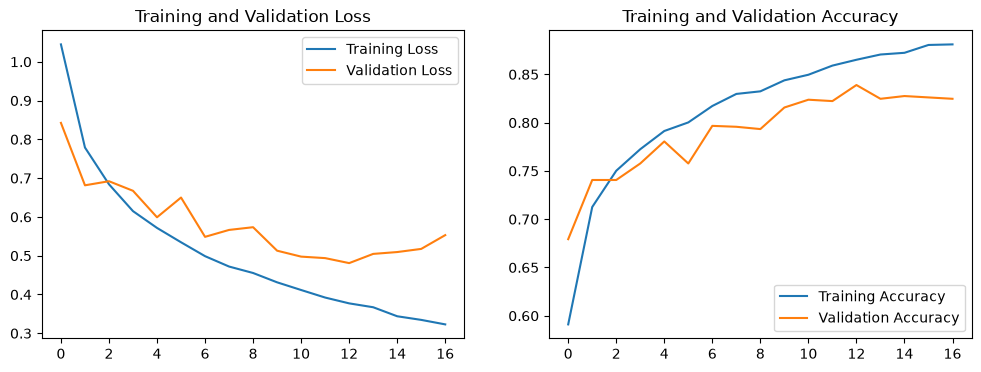

In [11]:
# TODO: plot train vs val loss, and train vs val accuracy, across epochs
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

plt.show()

## Task 5 — Evaluate

**What to do:**
1. Loop over `test_ds` (it yields batches of `(images, true_labels)`).
   For each batch:
   - Get predictions with `model.predict(images)` — this returns softmax
     probabilities, shape `(batch_size, 6)`.
   - Use `np.argmax(predictions, axis=1)` to convert probabilities into
     an actual predicted class index per image.
   - Collect both the true labels and predicted labels into two running
     lists across all batches (you need the full test set before comparing).
2. Print a `classification_report` (precision/recall/F1 per class) using
   `CLASS_NAMES` as labels. Look at this more carefully than plain
   accuracy — it reveals if one specific class is being handled worse
   than the others, even if the overall accuracy looks fine.
3. Print a `confusion_matrix`. Rows = true class, columns = predicted
   class. Look at which two classes get confused with each other most —
   glacier/mountain and sea/glacier are common mix-ups in this dataset;
   see if your model makes the same mistakes and think about why those
   pairs might look visually similar to a CNN.

In [15]:
# TODO: collect true and predicted labels across all batches in test_ds
all_true_labels = []
all_predicted_labels = []

# for images, labels in test_ds:
#     ...
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    all_true_labels.extend(labels.numpy())
    all_predicted_labels.extend(pred_classes)

In [16]:
# TODO: print classification_report using CLASS_NAMES
print("Classification Report:\n")
print(classification_report(all_true_labels, 
                            all_predicted_labels, 
                            target_names=CLASS_NAMES))

Classification Report:

              precision    recall  f1-score   support

   buildings       0.81      0.84      0.82       437
      forest       0.97      0.95      0.96       474
     glacier       0.83      0.76      0.79       553
    mountain       0.80      0.78      0.79       525
         sea       0.81      0.86      0.83       510
      street       0.86      0.87      0.86       501

    accuracy                           0.84      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.84      0.84      0.84      3000



In [17]:
# TODO: print confusion_matrix, labeling rows/columns clearly
cm = confusion_matrix(all_true_labels, all_predicted_labels)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[365   2   6   6  10  48]
 [  6 452   1   2   2  11]
 [  7   2 423  71  40  10]
 [  9   2  52 412  48   2]
 [ 17   1  27  21 441   3]
 [ 46   7   3   2   6 437]]


## Save the model

Once you're happy with it, save it so you don't have to retrain every
time (`model.save("your_filename.keras")`).

In [21]:
# TODO: save the trained model
model.save("intel_cnn_model.keras")

## Bonus (optional)

- Retrain without the augmentation layer and compare validation accuracy
  — does augmentation actually help on this dataset?
- Add a 4th conv block and see if accuracy improves, or if the train/val
  gap widens instead (a sign that added model capacity is causing more
  overfitting rather than helping).